<p align="center">
  <a href="https://vicena.ai"><strong>Built with Vicena</strong></a>
</p>

# Chemical Reactor Digital Twin, one-page presentation

This notebook is part of the Vicena Research Twins collection. It generates the public A4 landscape PDF and PNG from completed Level 0 synthetic reference runs. Numerical convergence is distinguished from chemical validity.

In [1]:
from pathlib import Path
import json, shutil, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from PIL import Image
project=Path.cwd()
if not (project/'README.md').exists(): project=project.parent
assert (project/'README.md').exists(), project
sys.path.insert(0,str(project/'src'))
from chemical_reactor_twin import ReactionNetwork, simulate_batch, simulate_cstr, simulate_pfr
assets=project/'assets'; docs_assets=project/'docs'/'assets'; docs_assets.mkdir(parents=True,exist_ok=True)
baseline=json.loads((project/'results/reference-runs/baseline.json').read_text())
response=json.loads((project/'results/reference-runs/temperature-response.json').read_text())
validation=json.loads((project/'results/reference-runs/validation.json').read_text())
print({'maturity':baseline['maturity'],'batch_conversion':baseline['results']['batch']['conversion'],'batch_selectivity_B':baseline['results']['batch']['selectivity_B'],'batch_peak_temperature_K':baseline['results']['batch']['peak_temperature_K'],'temperature_response_320_K':response['results']['cool_320_K']['conversion'],'temperature_response_340_K':response['results']['warm_340_K']['conversion'],'analytical_max_relative_error':validation['results']['max_relative_error']})

{'maturity': 'Level 0 executable reference', 'batch_conversion': 0.9337973722557376, 'batch_selectivity_B': 0.9673471523308793, 'batch_peak_temperature_K': 334.35561551474194, 'temperature_response_320_K': 0.6887316806215276, 'temperature_response_340_K': 0.7828706046490527, 'analytical_max_relative_error': 2.6776076538226335e-09}


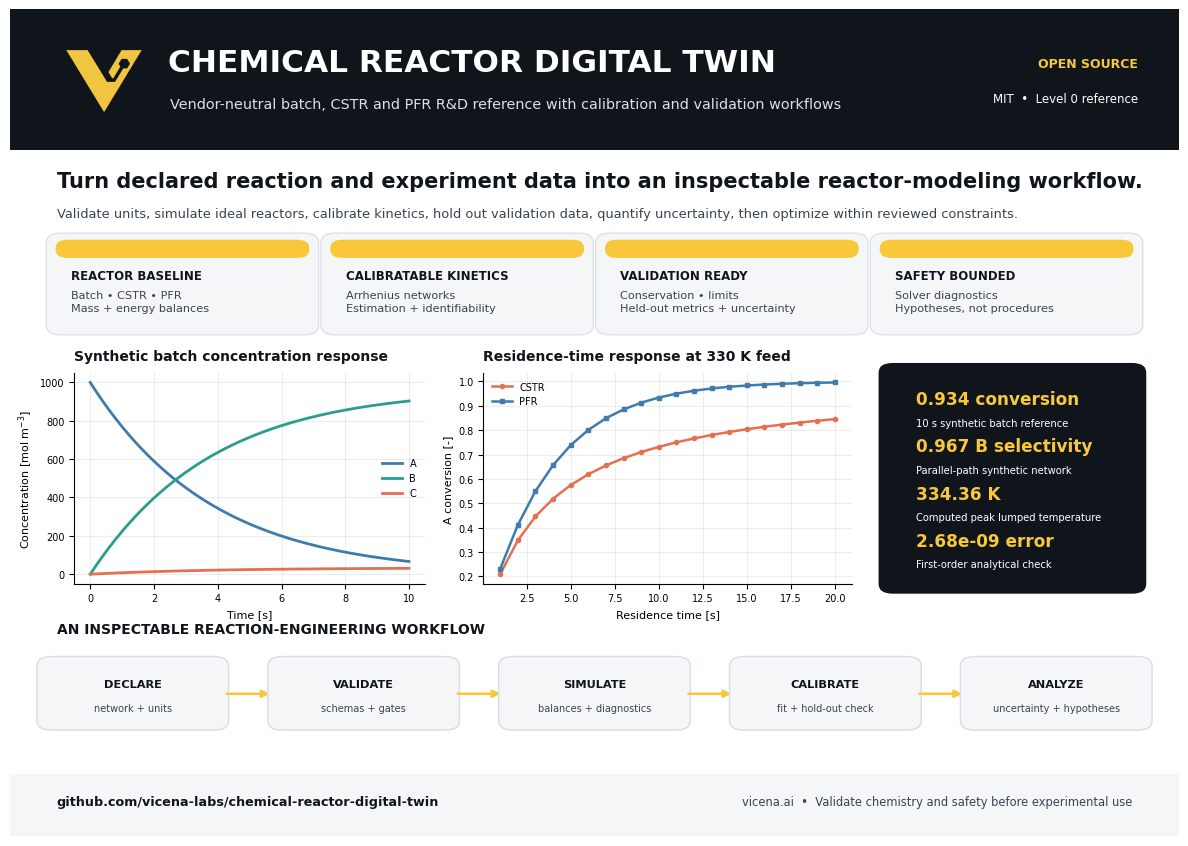

Saved: /root/sessions/473_open-source-chemical-reactor-digital-twin/chemical-reactor-digital-twin/Chemical_Reactor_Digital_Twin_OnePager.pdf
Saved: /root/sessions/473_open-source-chemical-reactor-digital-twin/chemical-reactor-digital-twin/assets/chemical-reactor-digital-twin-onepager.png
Copied: /root/sessions/473_open-source-chemical-reactor-digital-twin/chemical-reactor-digital-twin/docs/assets/chemical-reactor-digital-twin-onepager.png


In [2]:
network=ReactionNetwork(['A','B','C'],[[-1,1,0],[-1,0,1]],[20.,2.],[12000.,15000.],[[1,0,0],[1,0,0]],[-20000.,-30000.])
feed=np.array([1000.,0.,0.])
batch=simulate_batch(network,feed,330.,10.,volume=.001,ua=25.,coolant_temperature=330.)
taus=np.linspace(1,20,20); xc=[]; xp=[]
for tau in taus:
 c=simulate_cstr(network,feed,330.,float(tau),ua_over_volume=25000.,coolant_temperature=330.)
 p=simulate_pfr(network,feed,330.,float(tau),ua_over_volume=25000.,coolant_temperature=330.)
 xc.append(1-c.concentration[-1,0]/1000); xp.append(1-p.concentration[-1,0]/1000)
GOLD='#F8C73A'; DARK='#10151C'; MID='#394452'; LIGHT='#F4F6F8'; BLUE='#3F7CAC'; GREEN='#2A9D8F'; RED='#E76F51'
fig=plt.figure(figsize=(11.69,8.27),facecolor='white'); ax=fig.add_axes([0,0,1,1]); ax.set_axis_off(); ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.add_patch(FancyBboxPatch((0,.83),1,.17,boxstyle='square,pad=0',facecolor=DARK,edgecolor='none'))
logo=Image.open(assets/'vicena-logo.png'); la=fig.add_axes([.035,.852,.09,.12]); la.imshow(logo); la.axis('off')
ax.text(.135,.935,'CHEMICAL REACTOR DIGITAL TWIN',fontsize=22.5,fontweight='bold',color='white',va='center')
ax.text(.137,.885,'Vendor-neutral batch, CSTR and PFR R&D reference with calibration and validation workflows',fontsize=10.4,color='#D9E0E8',va='center')
ax.text(.965,.93,'OPEN SOURCE',fontsize=9,fontweight='bold',ha='right',color=GOLD); ax.text(.965,.887,'MIT  •  Level 0 reference',fontsize=8.5,ha='right',color='white')
ax.text(.04,.785,'Turn declared reaction and experiment data into an inspectable reactor-modeling workflow.',fontsize=15.0,fontweight='bold',color=DARK)
ax.text(.04,.748,'Validate units, simulate ideal reactors, calibrate kinetics, hold out validation data, quantify uncertainty, then optimize within reviewed constraints.',fontsize=9.4,color=MID)
cards=[('REACTOR BASELINE','Batch • CSTR • PFR\nMass + energy balances'),('CALIBRATABLE KINETICS','Arrhenius networks\nEstimation + identifiability'),('VALIDATION READY','Conservation • limits\nHeld-out metrics + uncertainty'),('SAFETY BOUNDED','Solver diagnostics\nHypotheses, not procedures')]
for (title,body),x in zip(cards,[.04,.275,.51,.745]):
 ax.add_patch(FancyBboxPatch((x,.615),.215,.105,boxstyle='round,pad=.009,rounding_size=.012',facecolor=LIGHT,edgecolor='#DCE2E8')); ax.add_patch(FancyBboxPatch((x,.700),.215,.020,boxstyle='round,pad=.001,rounding_size=.010',facecolor=GOLD,edgecolor='none')); ax.text(x+.012,.674,title,fontsize=8.5,fontweight='bold',color=DARK); ax.text(x+.012,.635,body,fontsize=8.1,color=MID,linespacing=1.35)
a1=fig.add_axes([.055,.305,.30,.255]); a1.plot(batch.coordinate,batch.concentration[:,0],label='A',color=BLUE,lw=2); a1.plot(batch.coordinate,batch.concentration[:,1],label='B',color=GREEN,lw=2); a1.plot(batch.coordinate,batch.concentration[:,2],label='C',color=RED,lw=2); a1.set_title('Synthetic batch concentration response',loc='left',fontsize=10,fontweight='bold',color=DARK,pad=9); a1.set_xlabel('Time [s]',fontsize=8); a1.set_ylabel('Concentration [mol m$^{-3}$]',fontsize=8); a1.tick_params(labelsize=7); a1.grid(alpha=.22); a1.legend(frameon=False,fontsize=7); [a1.spines[s].set_visible(False) for s in ['top','right']]
a2=fig.add_axes([.405,.305,.315,.255]); a2.plot(taus,xc,'o-',label='CSTR',color=RED,lw=1.8,ms=3); a2.plot(taus,xp,'s-',label='PFR',color=BLUE,lw=1.8,ms=3); a2.set_title('Residence-time response at 330 K feed',loc='left',fontsize=10,fontweight='bold',color=DARK,pad=9); a2.set_xlabel('Residence time [s]',fontsize=8); a2.set_ylabel('A conversion [-]',fontsize=8); a2.tick_params(labelsize=7); a2.grid(alpha=.22); a2.legend(frameon=False,fontsize=7); [a2.spines[s].set_visible(False) for s in ['top','right']]
ax.add_patch(FancyBboxPatch((.755,.305),.205,.255,boxstyle='round,pad=.012,rounding_size=.012',facecolor=DARK,edgecolor='none'))
metrics=[(f"{baseline['results']['batch']['conversion']:.3f} conversion",'10 s synthetic batch reference'),(f"{baseline['results']['batch']['selectivity_B']:.3f} B selectivity",'Parallel-path synthetic network'),(f"{baseline['results']['batch']['peak_temperature_K']:.2f} K",'Computed peak lumped temperature'),(f"{validation['results']['max_relative_error']:.2e} error",'First-order analytical check')]
y=.522
for value,label in metrics: ax.text(.775,y,value,fontsize=12.2,fontweight='bold',color=GOLD); ax.text(.775,y-.026,label,fontsize=7.2,color='white'); y-=.057
ax.text(.04,.245,'AN INSPECTABLE REACTION-ENGINEERING WORKFLOW',fontsize=10,fontweight='bold',color=DARK)
steps=[('DECLARE','network + units'),('VALIDATE','schemas + gates'),('SIMULATE','balances + diagnostics'),('CALIBRATE','fit + hold-out check'),('ANALYZE','uncertainty + hypotheses')]
centers=np.linspace(.105,.895,5)
for i,((title,sub),cx) in enumerate(zip(steps,centers)):
 ax.add_patch(FancyBboxPatch((cx-.075,.135),.15,.075,boxstyle='round,pad=.007,rounding_size=.012',facecolor=LIGHT,edgecolor='#D7DDE3')); ax.text(cx,.180,title,ha='center',fontsize=8.2,fontweight='bold',color=DARK); ax.text(cx,.151,sub,ha='center',fontsize=7,color=MID)
 if i<4: ax.add_patch(FancyArrowPatch((cx+.078,.172),(centers[i+1]-.078,.172),arrowstyle='-|>',mutation_scale=11,color=GOLD,lw=1.8))
ax.add_patch(FancyBboxPatch((0,0),1,.075,boxstyle='square,pad=0',facecolor=LIGHT,edgecolor='none')); ax.text(.04,.042,'github.com/vicena-labs/chemical-reactor-digital-twin',fontsize=9.2,fontweight='bold',color=DARK,va='center'); ax.text(.96,.042,'vicena.ai  •  Validate chemistry and safety before experimental use',fontsize=8.3,color=MID,ha='right',va='center')
pdf=project/'Chemical_Reactor_Digital_Twin_OnePager.pdf'; png=assets/'chemical-reactor-digital-twin-onepager.png'; fig.savefig(pdf,format='pdf',bbox_inches='tight',pad_inches=0); fig.savefig(png,dpi=160,bbox_inches='tight',pad_inches=0); shutil.copy2(png,docs_assets/png.name); plt.show(); print('Saved:',pdf); print('Saved:',png); print('Copied:',docs_assets/png.name)